A estimado: 5.095e+12 GeV


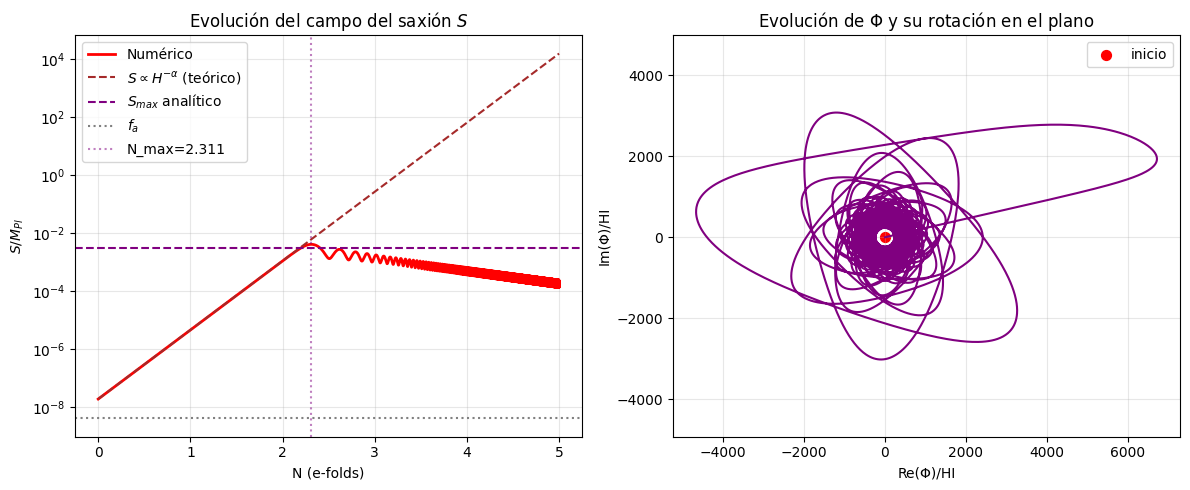

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Constantes necesarias (GeV)
Mpl = 2.435e18
H_I = 1e12
f_a = 1e10
lam = 1e-12
xi = 5.0
n = 7
w = 1.0  # ecuación de estado de época de dominación cinética

# Expresiones analíticas sacadas del tfg o del paper que serán necesarias
alpha = np.sqrt(2*xi/3)
denom_H = 72 * np.sqrt(3) * np.pi**2 * xi**(1.5)
H_max = H_I * (lam / denom_H)**(1/(2+2*alpha))
S_max = np.sqrt(6*xi/lam) * H_max
beta_est = 4*(4+2)/(12*n - 3*(4+2)*(3+w))   # Eq. D.6, p=4
A = np.sqrt(lam/ (2*beta_est**2)) * H_max * (Mpl/S_max)**(n-3)

# Condiciones iniciales del campo escalar (N=0)
S0 = H_I / (np.sqrt(6)* np.pi * (12*xi)**0.25)   # Expresión del tfg
dS_dt0 = np.sqrt(6*xi) * H_I * S0 # Expresión del tfg
S_prime0 = dS_dt0 / H_I  # dS/dN = (dS/dt)/H (cambiamos el tiempo por e-folds para obtener una mejor representación)
theta0 = np.pi/14   # ángulo inicial pequeño (concretamente el que permite sin(n*theta)=1)
theta_prime0 = 0.0 # el campo empieza sin velocidad angular

# Sistema de EDOs en N
def system(N, y):
    S, Sp, theta, thetap = y
    H = H_I * np.exp(-3*N)                     # w=1 -> H ∝ a^{-3}
    H2 = H*H
    H2_inv = 1.0/H2
    # Términos
    term_lin = 6*xi + lam*f_a*f_a * H2_inv
    term_quartic = lam * H2_inv
    term_breaking = 2*A * S**(n-1) * H2_inv / (Mpl**(n-3)) * np.cos(n*theta)
    centrifugal = S * thetap*thetap
    #Ecuación para S
    Spp = term_lin*S - term_quartic*S**3 + centrifugal - term_breaking
    # Ecuación para theta
    term_theta_break = 2*A * S**(n-2) * H2_inv / (Mpl**(n-3)) * np.sin(n*theta)
    thetapp = term_theta_break - 2*(Sp/S)*thetap
    return [Sp, Spp, thetap, thetapp]

# Integración mediante método BDF
N_span = (0.0, 5.0)
y0 = [S0, S_prime0, theta0, theta_prime0]
sol = solve_ivp(system, N_span, y0, method='BDF', rtol=1e-8, atol=1e-12, dense_output=True)

N = sol.t
S = sol.y[0]
theta = sol.y[2]
# Componentes real e imaginaria de Phi = (S/√2) e^{iθ}
Phi_real = (S/np.sqrt(2)) * np.cos(theta)
Phi_imag = (S/np.sqrt(2)) * np.sin(theta)

#Punto en el que se alcanza el máximo del saxión
idx_max = np.argmax(S)
N_max = N[idx_max]

# Figura 1 izquierda: S(N)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.semilogy(N, S/Mpl, 'r', linewidth=2, label='Numérico')
plt.semilogy(N,S0*(np.exp(3*N))**alpha/Mpl,linestyle='--',color='brown',label=r'$S\propto H^{-\alpha}$ (teórico)')
plt.axhline(S_max/Mpl, color='purple', linestyle='--', label='$S_{max}$ analítico')
plt.axhline(f_a/Mpl, color='gray', linestyle=':', label='$f_a$')
plt.axvline(N_max, color='purple', linestyle=':', alpha=0.5, label=f'N_max={round(N_max,3)}')
plt.xlabel('N (e‑folds)')
plt.ylabel(r'$S/M_{Pl}$')
plt.title(r'Evolución del campo del saxión $S$')
plt.legend()
plt.grid(True, alpha=0.3)

# Figura 1 derecha: trayectoria en plano complejo
plt.subplot(1,2,2)
plt.plot(Phi_real/H_I, Phi_imag/H_I, color='purple', linewidth=1.5)
plt.scatter(Phi_real[0]/H_I, Phi_imag[0]/H_I, color='red', s=50, label='inicio')
plt.xlabel('Re(Φ)/HI')
plt.ylabel('Im(Φ)/HI')
plt.axis('equal')
plt.legend()
plt.title(r'Evolución de $\Phi$ y su rotación en el plano')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

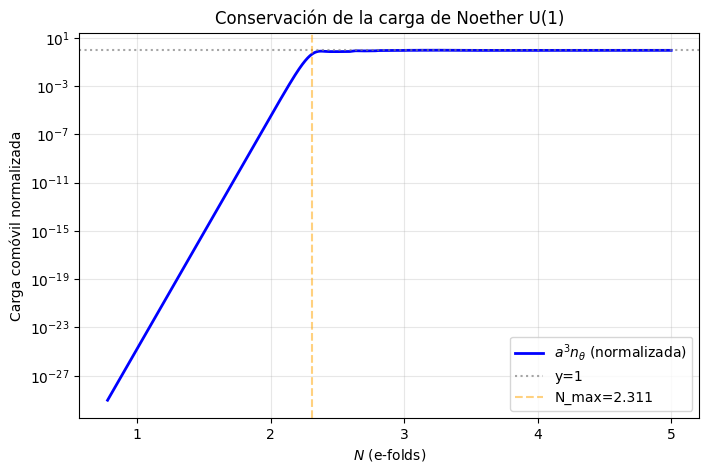

56123


In [32]:
# Usando los resultados de la sección previa
# Cálculo de n_theta con la simulación
dtheta_dN = sol.y[3]
H = H_I * np.exp(-3*N)
dtheta_dt = dtheta_dN * H # hace falta la derivada respecto al tiempo, no respecto a N que es la que tenía antes
n_theta = S**2 * dtheta_dt
a3_n_theta = np.exp(3 * N) * n_theta

# Valor de a cuando estamos en S_max
a_max3 = np.exp(3 * N_max)

# Expresión analítica según las expresiones del tfg
n_theta_max_analytic = beta_est * np.sin(n * theta0) * A * S_max**n / (H_max * Mpl**(n-3))
a3_n_theta_analytic = a_max3 * n_theta_max_analytic

# Normalizar para que la gráfica tienda a 1
a3_n_theta_norm = a3_n_theta / a3_n_theta_analytic

# Gráfica
plt.figure(figsize=(8,5))
plt.semilogy(N[100:], a3_n_theta_norm[100:], 'b-', linewidth=2, label='$a^3 n_\\theta$ (normalizada)')
plt.axhline(1, color='gray', linestyle=':', alpha=0.7, label='y=1')
plt.axvline(N_max, color='orange', linestyle='--', alpha=0.5, label=f'N_max={round(N_max,3)}')
plt.xlabel('$N$ (e‑folds)')
plt.ylabel('Carga comóvil normalizada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Conservación de la carga de Noether U(1)')
plt.show()

Iniciando marginalización...
Progreso: fila 1/70
Progreso: fila 2/70
Progreso: fila 3/70
Progreso: fila 4/70
Progreso: fila 5/70
Progreso: fila 6/70
Progreso: fila 7/70
Progreso: fila 8/70
Progreso: fila 9/70
Progreso: fila 10/70
Progreso: fila 11/70
Progreso: fila 12/70
Progreso: fila 13/70
Progreso: fila 14/70
Progreso: fila 15/70
Progreso: fila 16/70
Progreso: fila 17/70
Progreso: fila 18/70
Progreso: fila 19/70
Progreso: fila 20/70
Progreso: fila 21/70
Progreso: fila 22/70
Progreso: fila 23/70
Progreso: fila 24/70
Progreso: fila 25/70
Progreso: fila 26/70
Progreso: fila 27/70
Progreso: fila 28/70
Progreso: fila 29/70
Progreso: fila 30/70
Progreso: fila 31/70
Progreso: fila 32/70
Progreso: fila 33/70
Progreso: fila 34/70
Progreso: fila 35/70
Progreso: fila 36/70
Progreso: fila 37/70
Progreso: fila 38/70
Progreso: fila 39/70
Progreso: fila 40/70
Progreso: fila 41/70
Progreso: fila 42/70
Progreso: fila 43/70
Progreso: fila 44/70
Progreso: fila 45/70
Progreso: fila 46/70
Progreso: fila

(1e-13, 1e-07)

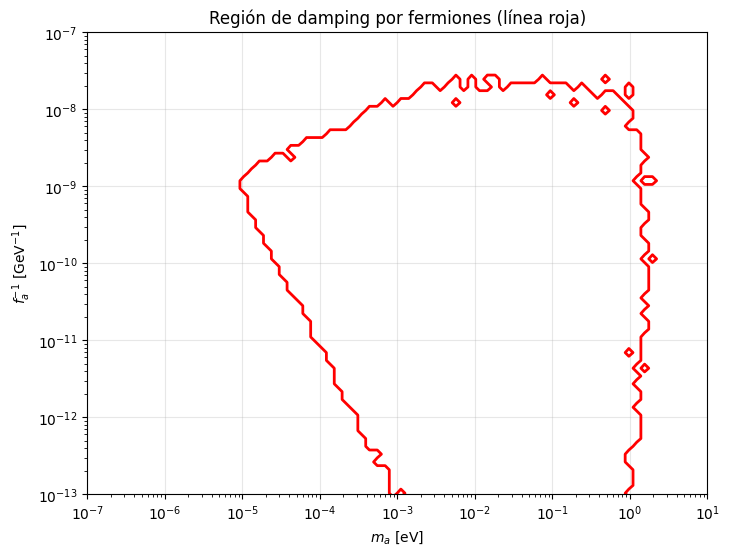

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# Constantes físicas 
M_PL = 2.435e18          # GeV 
G_STAR = 100          # grados de libertad relativistas (alta T)
XI = 5.0                 # acoplo no mínimo
N = 9                    # dimensión del operador U(1)-breaking
EPSILON = 0.5            # factor de asimetría promediado
ALPHA_S = 0.1            # acoplo fuerte
BETA = 0.5               # factor O(1) en A
OMEGA_CDM_H2 = 0.12
S0_OVER_RHOC = 0.563567     # (2 s0)/(rho_c/h^2) en [1/eV]
T_BBN = 1e-3             # GeV (~1 MeV)

# Factor alpha para w=1
alpha = np.sqrt(2*XI/3)
F_xi = 72 * np.sqrt(3) * np.pi**2 * XI**1.5  

# Definición de funciones auxiliares

def H_max(H_I, lam):
    return H_I * (lam / F_xi) ** (1/(2+2*alpha))

def S_max(H_I, lam):
    Hm = H_max(H_I, lam)
    return np.sqrt(6*XI/lam) * Hm

def H_ke(H_I, lam):
    Hm = H_max(H_I, lam)
    return (3*np.sqrt(3)*XI**3 * Hm**4) / (lam**1.5 * M_PL**3)

def Delta_N_ke(H_I, lam):
    Hm = H_max(H_I, lam)
    return np.log( np.sqrt(lam)/(np.sqrt(3)*XI) * M_PL/Hm )

def A_coupling(H_I, lam):
    Hm = H_max(H_I, lam)
    Sm = S_max(H_I, lam)
    return np.sqrt(lam/(2*BETA**2)) * Hm * (M_PL/Sm)**(N-3)

def T_damp(y):
    #ecuación sacada del paper
    return 7e8 * (y / 1e-4)**2 * (ALPHA_S / 0.1) * (100 / G_STAR)**0.5

def T_D(fa, H_I, lam, T_rh):
    Hm = H_max(H_I, lam)
    return (3*np.sqrt(15) * fa * Hm**2 * XI**1.5) / (np.pi * np.sqrt(G_STAR) * M_PL * T_rh * np.sqrt(lam))

def T_trap(fa, ma, lam,T_rh,H_I):
    # expresión obtenida en el tfg
    ma_GeV = ma * 1e-9
    num=5*ma*fa**2*M_PL*T_rh*F_xi**(1/(1+alpha))*lam**(alpha/(1+alpha))
    den=np.pi*15**0.5*EPSILON*XI**1.5*H_I**2*G_STAR**0.5
    return (num/den)**(1/3)
    
def T_axion(fa, lam):
    mS = np.sqrt(2*lam) * fa
    Gamma_ax = mS**3 / (32*np.pi * fa**2)
    return (90/(np.pi**2 * G_STAR))**0.25 * np.sqrt(Gamma_ax * M_PL)

def H_rh(T_rh):
    return np.sqrt(np.pi**2 * G_STAR / 90) * T_rh**2 / M_PL

# Cálculo de lambda para un conjunto (ma, H_I, T_rh)
def lambda_from_abundance(ma, H_I, T_rh):
    # ma en eV
    Y_needed = OMEGA_CDM_H2 / (S0_OVER_RHOC * ma) # abundancia comóvil de materia oscura según datos experimentales
    prefactor = (9 * np.sqrt(15) * EPSILON * H_I**2 * XI**1.5) / (np.pi * np.sqrt(G_STAR) * M_PL * T_rh * F_xi**(1/(1+alpha)))
    base = prefactor / Y_needed
    if base <= 0:
        return np.nan
    return base**((1+alpha)/alpha) # esta sería la lambda obtenida en función del resto de parámetros

# Verificación de todas las condiciones (Tabla 1, fermiones)
def check_fermion_conditions(ma, fa, H_I, T_rh, y):
    # ma: eV, fa: GeV, H_I: GeV, T_rh: GeV, y: adimensional
    lam = lambda_from_abundance(ma, H_I, T_rh)
    if np.isnan(lam) or lam <= 0:
        return False
    
    Hm = H_max(H_I, lam)
    Sm = S_max(H_I, lam)
    Hrh = H_rh(T_rh)
    Hk = H_ke(H_I, lam)
    A_val = A_coupling(H_I, lam)
    mS = np.sqrt(2*lam) * fa
    
    # Condiciones cosmológicas
    if not (Hm > Hrh):
        return False
    if not (Hrh > Hk):
        return False
    if A_val >= M_PL:
        return False
    if Sm**2 >= M_PL**2 / (XI * (5 + 4*np.sqrt(6*XI))):
        return False
    if Delta_N_ke(H_I, lam) > 10:
        return False
    Ttrap = T_trap(fa, ma, lam,T_rh,H_I)
    if Ttrap < T_BBN:
        return False
    
    # Condiciones específicas de fermiones
    Tdamp = T_damp(y)
    TD = T_D(fa, H_I, lam, T_rh)
    Tax = T_axion(fa, lam)
    
    if not (Tdamp > max(Ttrap, TD, Tax)):
        return False
    if not (Tdamp < T_rh):
        return False
        
    # Correción masa térmica
    if y*fa < Tdamp:
        m_th = y * Tdamp
    else:
        m_th = ALPHA_S * Tdamp**2 / fa
    if m_th > mS:
        return False
    
    # Correcciones cuánticas
    if y > (16*np.pi**2 * lam)**0.25:
        return False
    
    # Cota colisionadores
    if y * fa < 1000:   # 1 TeV
        return False
    
    # Evitar Delta N_eff
    if mS < fa**2 / M_PL:
        return False
    
    return True

# Marginalización sobre H_I, T_rh, y
def is_fermion_allowed(ma, fa, n_samples=5000):
    
    # Rangos logarítmicos (según el paper)
    log_H_I = np.random.uniform(8, 14, n_samples)
    log_T_rh = np.random.uniform(5, 16, n_samples)
    log_y = np.random.uniform(-10, -2, n_samples)
    
    for i in range(n_samples):
        H_I = 10**log_H_I[i]
        T_rh = 10**log_T_rh[i]
        y = 10**log_y[i]
        if check_fermion_conditions(ma, fa, H_I, T_rh, y):
            return True
    return False

# Generación del grid en el plano (ma, fa^{-1})

ma_vals = np.logspace(-6, 1, 70)          # eV
fa_vals = np.logspace(7, 14, 70)          # GeV
inv_fa_vals = 1.0 / fa_vals

# Para almacenar resultado (True/False)
Z = np.zeros((len(fa_vals), len(ma_vals)), dtype=bool)

print("Iniciando marginalización...")
for i, fa in enumerate(fa_vals):
    for j, ma in enumerate(ma_vals):
        Z[i, j] = is_fermion_allowed(ma, fa, n_samples=6000)  # Ajustar número para precisión/velocidad
    print(f"Progreso: fila {i+1}/{len(fa_vals)}")

# Gráfico
M_grid, InvF_grid = np.meshgrid(ma_vals, inv_fa_vals)

plt.figure(figsize=(8,6))
# Contorno de la región permitida
plt.contour(M_grid, InvF_grid, Z, levels=[0.5], colors='red', linewidths=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$m_a$ [eV]')
plt.ylabel(r'$f_a^{-1}$ [GeV$^{-1}$]')
plt.title('Región de damping por fermiones (línea roja)')
plt.grid(alpha=0.3)
plt.xlim(1e-7, 10)
plt.ylim(1e-13, 1e-7)